In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv
/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/data-dictionary.csv


Dataset Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


Missing Values After Cleaning:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64
Scaled Data Shape: (167, 9)


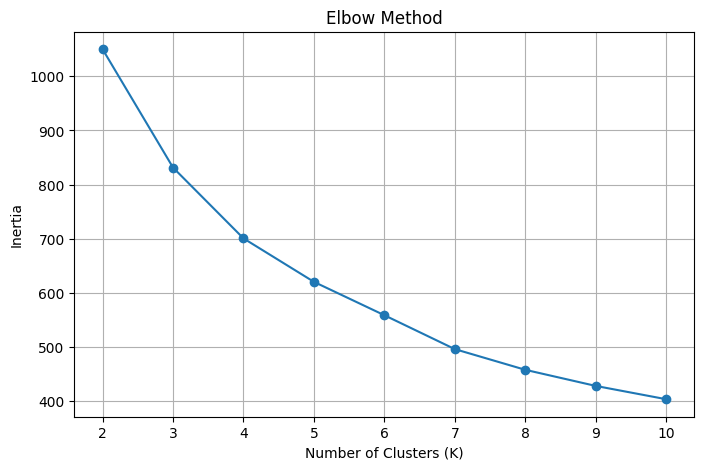

Cluster Counts:
KMeans_Cluster
2    84
1    47
0    36
Name: count, dtype: int64

Silhouette Score: 0.2833

DBSCAN Cluster Counts:
DBSCAN_Cluster
 0    137
-1     30
Name: count, dtype: int64


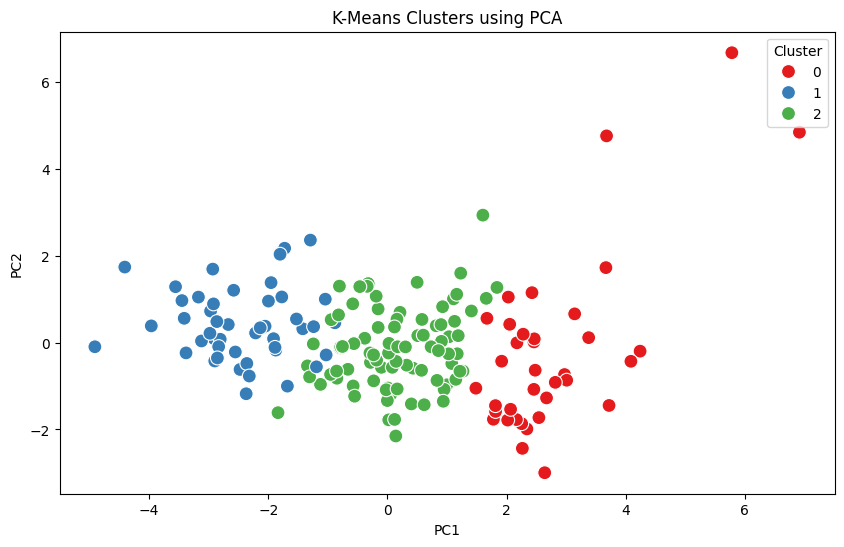


Cluster Summary:


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,DBSCAN_Cluster
KMeans_Cluster,,,,,,,,,,
0,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444,-0.250000
1,92.961702,29.151277,6.388511,42.323404,3942.404255,12.019681,59.187234,5.008085,1922.382979,-0.340426
2,21.927381,40.243917,6.200952,47.473404,12305.595238,7.600905,72.814286,2.307500,6486.452381,-0.059524


Output file saved successfully.


In [6]:
# STEP 1: Import Required Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
# STEP 2: Load Dataset

df = pd.read_csv('/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv')

print("Dataset Shape:", df.shape)
display(df.head())

# STEP 3: Data Cleaning
# Remove whitespace from column names
df.columns = df.columns.str.strip()

# Remove duplicate rows
df = df.drop_duplicates()

# Convert numeric columns to numeric datatype
for col in df.columns:
    if col != 'country':
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Handle missing values using median
numeric_cols = df.select_dtypes(include=np.number).columns

imputer = SimpleImputer(strategy='median')
df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

print("Missing Values After Cleaning:")
print(df.isnull().sum())

# STEP 4: Remove Country Name and Scale Data

countries = df['country']

X = df.drop('country', axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled Data Shape:", X_scaled.shape)

# STEP 5: Elbow Method


inertia_values = []

k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_values, inertia_values, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

# STEP 6: Train K-Means with best_k = 3


best_k = 3

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

df['KMeans_Cluster'] = kmeans_labels

print("Cluster Counts:")
print(df['KMeans_Cluster'].value_counts())

# STEP 7: Silhouette Score

sil_score = silhouette_score(X_scaled, kmeans_labels)

print("\nSilhouette Score:", round(sil_score,4))

# STEP 8: DBSCAN Clustering

dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_scaled)

df['DBSCAN_Cluster'] = dbscan_labels

print("\nDBSCAN Cluster Counts:")
print(df['DBSCAN_Cluster'].value_counts())

# STEP 9: PCA Visualization

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2']
)

pca_df['Cluster'] = kmeans_labels

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set1',
    s=100
)

plt.title('K-Means Clusters using PCA')
plt.show()
# Cluster Summary
cluster_summary = df.groupby('KMeans_Cluster').mean(numeric_only=True)

print("\nCluster Summary:")
display(cluster_summary)
# Save Result

df.to_csv("Country_Clustered_Output.csv", index=False)

print("Output file saved successfully.")


# Socio-Economic Observations

1. High-Mortality Cluster
   - One cluster contains countries with the highest child mortality rates and lower life expectancy, indicating weaker healthcare systems and lower levels of socio-economic development.

2. Top-Tier Economic Zone
   - Another cluster consists of countries with the highest GDP per capita and income levels. These countries represent developed economies with strong economic performance and better living standards.

3. Low-Development Area
   - Countries grouped in the low-income cluster generally show lower exports, lower GDP per capita, and weaker health indicators, suggesting lower development levels.

4. Cluster Separation
   - The PCA visualization shows a clear separation between country groups, demonstrating that K-Means successfully identified meaningful socio-economic segments.

5. Clustering Performance
   - The Silhouette Score indicates that the clusters are reasonably well-defined and that countries within each cluster share similar socio-economic characteristics.